In [34]:
import sys
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Ajouter le répertoire parent au path pour importer perceptron
sys.path.insert(0, str(pathlib.Path().resolve().parent))
from perceptron import Perceptron

DATAFRAME = '../data/bcw_simple_cleaning.csv'

In [35]:
df = pd.read_csv(DATAFRAME)
df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [36]:
X = df.drop(columns=["target"]).values
y = df["target"].values  # 1=Malignant, 0=Benign

print(X.shape, y.shape)

(569, 30) (569,)


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((455, 30), (114, 30), (455,), (114,))

In [38]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

PCA2 variance totale: 0.631387776559559


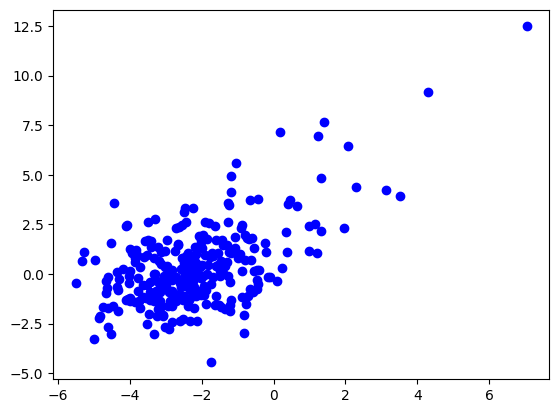

In [39]:
pca2 = PCA(n_components=2, random_state=42)
X_train_pca2 = pca2.fit_transform(X_train_s)
X_test_pca2 = pca2.transform(X_test_s)

print("PCA2 variance totale:", pca2.explained_variance_ratio_.sum())
plt.plot(X_train_pca2[y_train == 0][:, 0], X_train_pca2[y_train == 0][:, 1], "bo", label="Benign")

In [40]:
# PCA 95% (modèle)
pca95 = PCA(n_components=0.95, random_state=42)
X_train_pca = pca95.fit_transform(X_train_s)
X_test_pca = pca95.transform(X_test_s)

print("Nb composantes (95%):", pca95.n_components_)
print("Variance totale:", pca95.explained_variance_ratio_.sum())

Nb composantes (95%): 10
Variance totale: 0.9520691014391004


In [41]:
model = Perceptron(learning_rate=0.01, n_epochs=200)
model.fit(X_train_pca, y_train)

print("Erreurs (10 dernières époques):", model.errors_[-10:])

Erreurs (10 dernières époques): [23, 16, 14, 16, 14, 18, 16, 18, 20, 15]


In [42]:
y_pred = model.predict(X_test_pca)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")

Accuracy  : 0.9649
Precision : 0.9318
Recall    : 0.9762
F1-score  : 0.9535


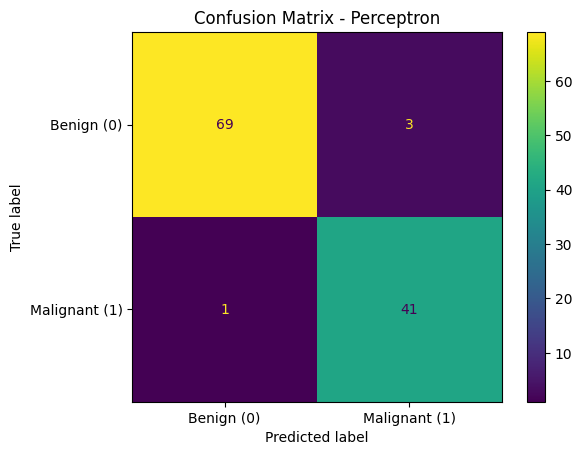

In [43]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Benign (0)", "Malignant (1)"])
disp.plot(values_format="d")
plt.title("Confusion Matrix - Perceptron")
plt.show()